# Multiple Linear Regression

In [2]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# Read the dataset
df = pd.read_csv('data/economic_index.csv')
df.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [4]:
# drop the unnecessary columns (year and month are not related to find the index_price)
df.drop(['Unnamed: 0','year', 'month'], axis=1, inplace=True)
df.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [5]:
# check null values
df.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

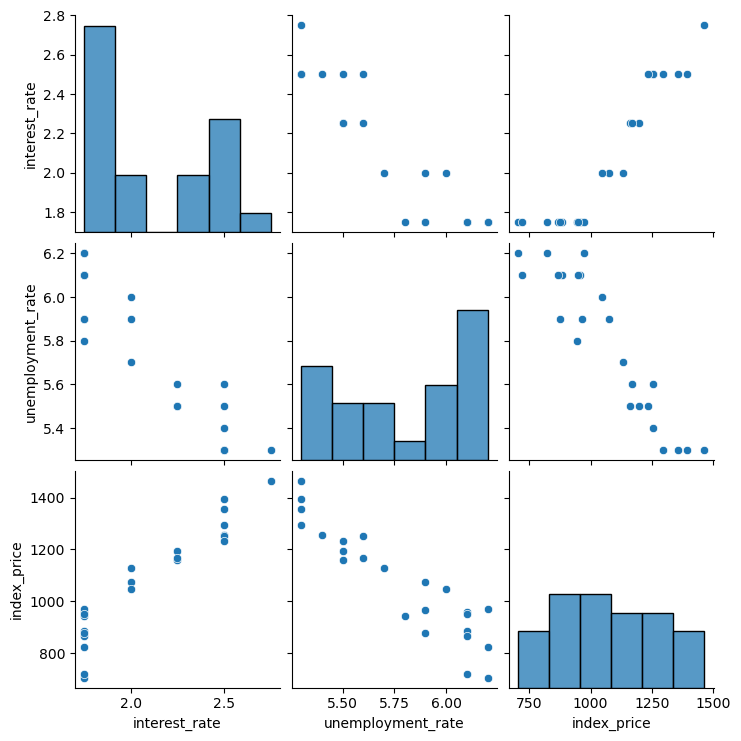

In [6]:
# let's visualize the data (multivariate analysis)
sns.pairplot(df)
plt.show()

In [7]:
# interest_rate and index_price has positive correlation
# unemployement_rate and index_price has negative correlation
df.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


In [8]:
# divide the data into indepdendent and dependent features
X = df.iloc[:, :-1]
y = df.iloc[:, -1]
X.shape, y.shape

((24, 2), (24,))

In [9]:
X[:5]

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [10]:
y[:5]

0    1464
1    1394
2    1357
3    1293
4    1256
Name: index_price, dtype: int64

In [11]:
# split the data into train and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((19, 2), (5, 2), (19,), (5,))

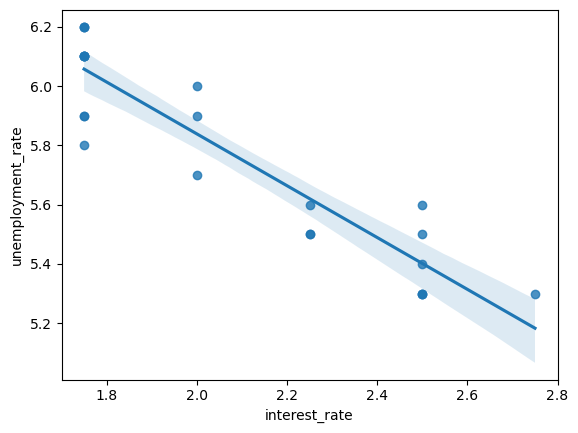

In [14]:
# visualize the best fit line using regplot in seaborn (it works with only two features)
sns.regplot(x='interest_rate', y='unemployment_rate', data=df)
plt.show()

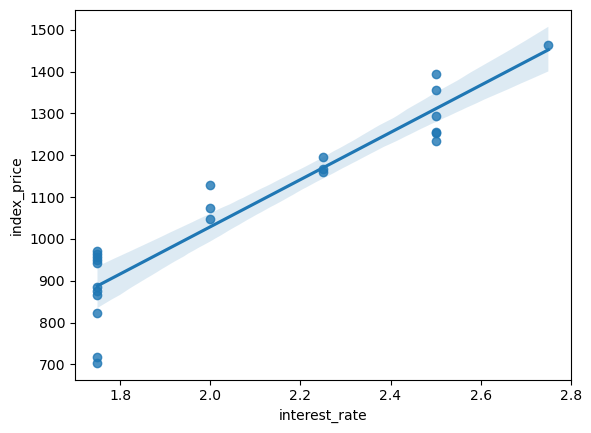

In [15]:
sns.regplot(x='interest_rate', y='index_price', data=df)
plt.show()

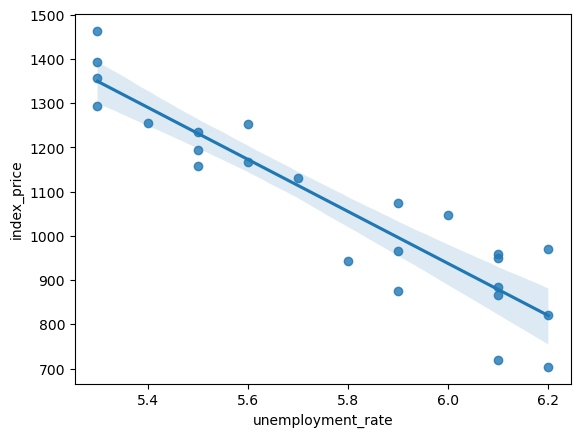

In [16]:
sns.regplot(x='unemployment_rate', y='index_price', data=df)
plt.show()

In [17]:
# standardize the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# Scale the train data using fit_transform method
X_train = scaler.fit_transform(X_train)
# Scale the test data using transform method
X_test = scaler.transform(X_test)

In [18]:
X_train[:5]

array([[ 0.55339859, -0.53244666],
       [-0.9486833 ,  0.41597395],
       [ 1.30443953, -1.48086727],
       [-0.9486833 ,  1.36439457],
       [ 1.30443953, -0.53244666]])

In [20]:
X_test[:5]

array([[ 0.55339859, -0.84858687],
       [-0.9486833 ,  1.36439457],
       [ 2.05548048, -1.48086727],
       [-0.9486833 ,  1.04825436],
       [-0.19764235,  0.41597395]])

In [21]:
# fit the data to the linear model
from sklearn.linear_model import LinearRegression
regression = LinearRegression()
regression.fit(X_train, y_train)

LinearRegression()

In [23]:
# cross validation
from sklearn.model_selection import cross_val_score
validation_score = cross_val_score(regression, X_train, y_train, scoring='neg_mean_squared_error', cv=3)
np.mean(validation_score)

np.float64(-5674.031667186767)

In [24]:
# Prediction of the model
y_pred = regression.predict(X_test)

In [25]:
# Evaluating the model using performance metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2_score = r2_score(y_test, y_pred)
adjusted_r2_score = 1 - (1-r2_score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)
print("MAE: ", mae)
print("MSE: ", mse)
print("RMSE: ", rmse)
print("R Squared: ", r2_score)
print("Adjusted R Squared: ", adjusted_r2_score)

MAE:  71.71878409976625
MSE:  6957.10530325883
RMSE:  83.40926389351982
R Squared:  0.8254940547158576
Adjusted R Squared:  0.6509881094317151


In [26]:
# residuals
residuals = y_test - y_pred
residuals

8     -45.144037
16    149.373967
0      57.614653
18     26.318628
11     80.142634
Name: index_price, dtype: float64

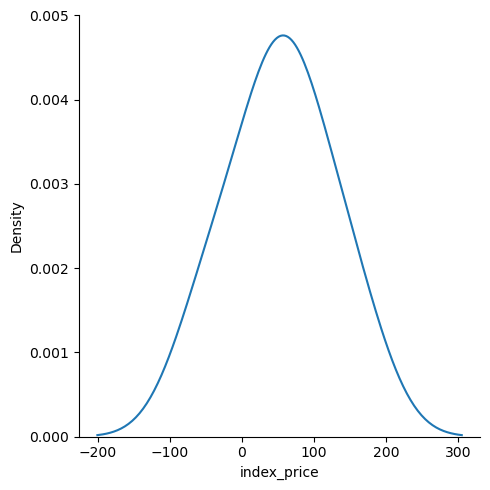

In [27]:
# plot the residuals
sns.displot(residuals, kind='kde')

In [29]:
# OLS linear regression
import statsmodels.api as sm
model = sm.OLS(y_train, X_train).fit()
model.summary()

C:\Users\vrudi\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=19 observations were given.
  return hypotest_fun_in(*args, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            index_price   R-squared (uncentered):                   0.033
Model:                            OLS   Adj. R-squared (uncentered):             -0.081
Method:                 Least Squares   F-statistic:                             0.2916
Date:                Wed, 28 Jan 2026   Prob (F-statistic):                       0.751
Time:                        20:14:03   Log-Likelihood:                         -159.34
No. Observations:                  19   AIC:                                      322.7
Df Residuals:                      17   BIC:                                      324.6
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            86.6335    647.232      0.134      0.895   -1278.906    1452.173
x2          -114.0486    647.232     -0.176      0.862   -1479.588    1251.491
==============================================================================
Omnibus:                        0.676   Durbin-Watson:                   0.007
Prob(Omnibus):                  0.713   Jarque-Bera (JB):                0.526
Skew:                          -0.369   Prob(JB):                        0.769
Kurtosis:                       2.656   Cond. No.                         4.82
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [30]:
print('Coefficient: ', regression.coef_)
print('Intercept: ', regression.intercept_)

Coefficient:  [  86.63351334 -114.04857249]
Intercept:  1059.4210526315792
